In [2]:
!pip install -q openai datasets huggingface-hub numpy pandas matplotlib seaborn scipy


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\loalm\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
from dotenv import load_dotenv
import os
import json
import re
from dataclasses import dataclass, field, asdict
from datetime import datetime
from enum import Enum
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
HF_TOKEN = os.getenv("HF_TOKEN")
if not OPENROUTER_API_KEY:
    raise ValueError("OPENROUTER_API_KEY не найден в .env")
if not HF_TOKEN:
    raise ValueError("HF_TOKEN не найден в .env")

os.environ["OPENROUTER_API_KEY"] = OPENROUTER_API_KEY
os.environ["HF_TOKEN"] = HF_TOKEN



RUN_TAG = "baseline_3agents_3models"     # метка серии экспериментов
RESULTS_DIR = "experiments"
os.makedirs(RESULTS_DIR, exist_ok=True)

np.random.seed(42)
pd.set_option("display.width", 200)

print(f"Результаты будут писаться в ./{RESULTS_DIR}/ с меткой '{RUN_TAG}'")

Результаты будут писаться в ./experiments/ с меткой 'baseline_3agents_3models'


In [4]:
class TaskType(Enum):
    RESEARCH = "research"
    ANALYSIS = "analysis"
    CODING = "coding"
    REASONING = "reasoning"
    SUMMARIZATION = "summarization"


class AgentRole(Enum):
    RESEARCHER = "researcher"
    ANALYST = "analyst"
    PROGRAMMER = "programmer"
    REASONER = "reasoner"
    WRITER = "writer"


class LLMModel(Enum):
    GPT4 = "gpt-4"
    CLAUDE3 = "claude-3"
    LLAMA3 = "llama-3"
    GEMMA = "gemma"
    MIXTRAL = "mixtral"


@dataclass
class Subtask:
    """Подзадача после декомпозиции исходной задачи GAIA."""
    id: str
    description: str
    task_type: TaskType
    parent_task_id: str
    step_number: int


@dataclass
class Agent:
    """Агент с ролевой специализацией."""
    id: str
    role: AgentRole
    tools: List[str] = field(default_factory=list)
    memory_size: int = 1000


@dataclass
class ModelPackage:
    """Пакет ресурса: модель + токен-бюджет. Все пакеты одной стоимости."""
    model: LLMModel
    token_budget: int
    cost: float


@dataclass
class Allocation:
    """Результат распределения одной подзадачи."""
    subtask: Subtask
    agent: Agent
    model_package: ModelPackage
    predicted_utility: float


print("Предметная модель загружена:",
      f"{len(TaskType)} типов задач, {len(AgentRole)} ролей, {len(LLMModel)} моделей")

Предметная модель загружена: 5 типов задач, 5 ролей, 5 моделей


Доступ к моделям через OpenRouter + учёт стоимости

In [8]:
@dataclass
class ModelConfig:
    """Описание модели: id в OpenRouter + прайс за 1k токенов."""
    name: str
    openrouter_id: str
    context_window: int
    cost_per_1k_input: float
    cost_per_1k_output: float
    description: str = ""

    def calculate_cost(self, input_tokens: int, output_tokens: int) -> float:
        return round(
            input_tokens / 1000 * self.cost_per_1k_input
            + output_tokens / 1000 * self.cost_per_1k_output,
            6,
        )


MODEL_CONFIGS: Dict[str, ModelConfig] = {
    "gpt4": ModelConfig(
        name="GPT-4o-mini",
        openrouter_id="openai/gpt-4o-mini",
        context_window=8192,
        cost_per_1k_input=0.00015,
        cost_per_1k_output=0.0006,
        description="дешёвая модель OpenAI, база для оракула",
    ),
    "claude3": ModelConfig(
        name="Claude-3 Haiku",
        openrouter_id="anthropic/claude-3-haiku",
        context_window=200000,
        cost_per_1k_input=0.00025,
        cost_per_1k_output=0.00125,
        description="быстрая модель Anthropic, хороша для анализа и суммаризации",
    ),
    "llama3": ModelConfig(
        name="Llama-3 8B Instruct",
        openrouter_id="meta-llama/llama-3.1-8b-instruct",
        context_window=8192,
        cost_per_1k_input=0.00003,
        cost_per_1k_output=0.00006,
        description="открытая модель Meta, самая дешёвая в наборе",
    ),
}


class LLMModelInstance:
    """Один экземпляр модели через OpenRouter со статистикой расходов."""

    def __init__(self, config: ModelConfig, api_key: Optional[str] = None):
        self.config = config
        self.api_key = api_key or os.getenv("OPENROUTER_API_KEY")
        if not self.api_key:
            raise ValueError("OPENROUTER_API_KEY не задан")

        self.client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=self.api_key)
        self.total_tokens_used = 0
        self.total_cost = 0.0
        self.request_count = 0

    def generate(
        self,
        prompt: str,
        system_prompt: Optional[str] = None,
        max_tokens: int = 1000,
        temperature: float = 0.7,
        **kwargs,
    ) -> Dict[str, Any]:
        messages: List[Dict[str, str]] = []
        if system_prompt:
            messages.append({"role": "system", "content": system_prompt})
        messages.append({"role": "user", "content": prompt})

        try:
            response = self.client.chat.completions.create(
                model=self.config.openrouter_id,
                messages=messages,
                max_tokens=max_tokens,
                temperature=temperature,
                **kwargs,
            )
            usage = response.usage
            cost = self.config.calculate_cost(usage.prompt_tokens, usage.completion_tokens)

            self.total_tokens_used += usage.total_tokens
            self.total_cost += cost
            self.request_count += 1

            return {
                "content": response.choices[0].message.content,
                "input_tokens": usage.prompt_tokens,
                "output_tokens": usage.completion_tokens,
                "total_tokens": usage.total_tokens,
                "cost": cost,
                "model": self.config.name,
                "finish_reason": response.choices[0].finish_reason,
            }

        except Exception as exc:
            print(f"[{self.config.name}] ошибка вызова: {exc}")
            return {
                "content": f"ERROR: {exc}",
                "input_tokens": 0, "output_tokens": 0, "total_tokens": 0,
                "cost": 0.0, "model": self.config.name, "error": str(exc),
            }

    def get_stats(self) -> Dict[str, Any]:
        return {
            "model": self.config.name,
            "requests": self.request_count,
            "total_tokens": self.total_tokens_used,
            "total_cost": round(self.total_cost, 6),
            "avg_cost_per_request": round(self.total_cost / self.request_count, 6) if self.request_count else 0,
        }


class ModelFactory:
    """Создание экземпляров моделей по ключу из MODEL_CONFIGS."""

    @staticmethod
    def create_model(model_key: str, api_key: Optional[str] = None) -> LLMModelInstance:
        if model_key not in MODEL_CONFIGS:
            raise ValueError(f"Модель '{model_key}' не найдена. Доступные: {list(MODEL_CONFIGS)}")
        return LLMModelInstance(MODEL_CONFIGS[model_key], api_key)

    @staticmethod
    def create_all_models(api_key: Optional[str] = None) -> Dict[str, LLMModelInstance]:
        return {key: ModelFactory.create_model(key, api_key) for key in MODEL_CONFIGS}


print("Модели сконфигурированы:", {k: v.openrouter_id for k, v in MODEL_CONFIGS.items()})

Модели сконфигурированы: {'gpt4': 'openai/gpt-4o-mini', 'claude3': 'anthropic/claude-3-haiku', 'llama3': 'meta-llama/llama-3.1-8b-instruct'}


In [6]:
class OpenRouterAgent:
    """Агент с ролевым системным промптом, работающий через OpenRouter."""

    SYSTEM_PROMPTS = {
        "researcher": (
            "Ты эксперт-исследователь в мультиагентной системе.\n"
            "Твоя задача: находить и анализировать информацию. Будь точным, "
            "приводи источники когда возможно. Отвечай подробно, но по делу."
        ),
        "analyst": (
            "Ты аналитик в мультиагентной системе.\n"
            "Твоя задача: анализировать данные, находить закономерности, делать выводы. "
            "Используй логические рассуждения, проверяй свои выводы."
        ),
        "programmer": (
            "Ты программист в мультиагентной системе.\n"
            "Твоя задача: писать код, решать технические проблемы, объяснять алгоритмы. "
            "Пиши чистый, документированный код с примерами."
        ),
        "writer": (
            "Ты писатель/суммаризатор в мультиагентной системе.\n"
            "Твоя задача: структурировать информацию, писать отчеты, делать выводы. "
            "Будь ясным, структурированным, избегай избыточности."
        ),
        "evaluator": (
            "Ты оценщик совместимости в мультиагентной системе. "
            "Ты возвращаешь только число — без пояснений."
        ),
    }

    def __init__(
        self,
        agent_id: str,
        role: str,
        default_model_key: str = "gpt4",
        api_key: Optional[str] = None,
    ):
        self.agent_id = agent_id
        self.role = role
        self.api_key = api_key or os.getenv("OPENROUTER_API_KEY")
        self.models = ModelFactory.create_all_models(self.api_key)
        self.default_model = self.models[default_model_key]
        self.history: List[Dict[str, Any]] = []

    def execute_task(
        self,
        task_description: str,
        context: Optional[str] = None,
        model_key: Optional[str] = None,
        **kwargs,
    ) -> Dict[str, Any]:
        model = self.models.get(model_key, self.default_model) if model_key else self.default_model
        started = datetime.now()

        result = model.generate(
            prompt=self._build_prompt(task_description, context),
            system_prompt=self.SYSTEM_PROMPTS.get(self.role, "Ты полезный AI-ассистент."),
            **kwargs,
        )

        entry = {
            "timestamp": started.isoformat(),
            "agent_id": self.agent_id,
            "role": self.role,
            "model": model.config.name,
            "task": task_description[:200],
            "response": (result["content"] or "")[:500],
            "tokens": result["total_tokens"],
            "cost": result["cost"],
            "duration_ms": int((datetime.now() - started).total_seconds() * 1000),
        }
        self.history.append(entry)

        return {
            "agent": self.agent_id,
            "role": self.role,
            "model": model.config.name,
            "response": result["content"],
            "metadata": result,
            "history_entry": entry,
        }

    @staticmethod
    def _build_prompt(task: str, context: Optional[str]) -> str:
        if not context:
            return task
        return (
            f"Контекст (результаты предыдущих шагов):\n{context}\n\n"
            f"Текущая задача:\n{task}\n\nВыполни задачу, учитывая контекст выше."
        )

    def get_agent_stats(self) -> Dict[str, Any]:
        return {
            "agent_id": self.agent_id,
            "role": self.role,
            "total_requests": len(self.history),
            "total_tokens": sum(e["tokens"] for e in self.history),
            "total_cost": round(sum(e["cost"] for e in self.history), 6),
            "model_stats": {m.config.name: m.get_stats() for m in self.models.values()},
        }


print("Класс агента готов. Доступные роли:", list(OpenRouterAgent.SYSTEM_PROMPTS))

Класс агента готов. Доступные роли: ['researcher', 'analyst', 'programmer', 'writer', 'evaluator']


In [9]:
# Дымовой тест API

# Один дешёвый вызов на каждую из трёх моделей. 
# Нужен, чтобы отделить «модель недоступна / сменился slug / кончился баланс» от проблем самого эксперимента.

smoke = OpenRouterAgent(agent_id="smoke_test", role="evaluator", default_model_key="gpt4")

for key in MODEL_CONFIGS:
    out = smoke.execute_task(
        task_description="Ответь одним числом: 0.75",
        model_key=key,
        max_tokens=10,
        temperature=0.0,
    )
    meta = out["metadata"]
    status = "ERROR" if "error" in meta else "OK"
    print(f"{status:5} | {MODEL_CONFIGS[key].name:20} | ответ: {str(out['response'])[:40]!r} "
          f"| токенов: {meta['total_tokens']:3} | ${meta['cost']:.6f}")

print("\nЕсли где-то ERROR — проверьте ключ и актуальность openrouter_id в MODEL_CONFIGS.")

OK    | GPT-4o-mini          | ответ: '0.75' | токенов:  48 | $0.000009
OK    | Claude-3 Haiku       | ответ: '75' | токенов:  64 | $0.000021
OK    | Llama-3 8B Instruct  | ответ: '0.75' | токенов:  58 | $0.000002

Если где-то ERROR — проверьте ключ и актуальность openrouter_id в MODEL_CONFIGS.


Оракул: гибридная генерация «кубика оценок»

Две ступени: (1) эвристика по матрицам совместимости «роль×тип задачи» и «модель×тип задачи»; (2) уточнение через LLM только для самых неопределённых комбинаций (те, что ближе всего к 0.5). Плюс кэш, отсечение заведомо плохих пар и пропуск LLM при очень низкой/очень высокой эвристике - именно это даёт заявленную экономию ~70%

In [10]:
class OptimizedOracleFixed:
    """Гибридный оракул: эвристика + выборочное уточнение через LLM.
    """

    ROLE_TASK_COMPATIBILITY = {
        AgentRole.RESEARCHER: {
            TaskType.RESEARCH: 0.9, TaskType.ANALYSIS: 0.7, TaskType.CODING: 0.2,
            TaskType.REASONING: 0.6, TaskType.SUMMARIZATION: 0.5,
        },
        AgentRole.ANALYST: {
            TaskType.RESEARCH: 0.6, TaskType.ANALYSIS: 0.9, TaskType.CODING: 0.4,
            TaskType.REASONING: 0.8, TaskType.SUMMARIZATION: 0.7,
        },
        AgentRole.PROGRAMMER: {
            TaskType.RESEARCH: 0.3, TaskType.ANALYSIS: 0.5, TaskType.CODING: 0.9,
            TaskType.REASONING: 0.7, TaskType.SUMMARIZATION: 0.4,
        },
    }

    MODEL_TASK_COMPATIBILITY = {
        LLMModel.GPT4: {
            TaskType.RESEARCH: 0.85, TaskType.ANALYSIS: 0.9, TaskType.CODING: 0.75,
            TaskType.REASONING: 0.88, TaskType.SUMMARIZATION: 0.82,
        },
        LLMModel.CLAUDE3: {
            TaskType.RESEARCH: 0.82, TaskType.ANALYSIS: 0.87, TaskType.CODING: 0.65,
            TaskType.REASONING: 0.83, TaskType.SUMMARIZATION: 0.88,
        },
        LLMModel.LLAMA3: {
            TaskType.RESEARCH: 0.7, TaskType.ANALYSIS: 0.75, TaskType.CODING: 0.85,
            TaskType.REASONING: 0.78, TaskType.SUMMARIZATION: 0.72,
        },
    }

    LOW_COMPATIBILITY_PATTERNS = [
        (AgentRole.PROGRAMMER, TaskType.RESEARCH),
        (AgentRole.RESEARCHER, TaskType.CODING),
        (AgentRole.PROGRAMMER, TaskType.SUMMARIZATION),
    ]

    COST_MULTIPLIERS = {LLMModel.LLAMA3: 1.05, LLMModel.GPT4: 1.0, LLMModel.CLAUDE3: 0.98}

    ROLE_DESCRIPTIONS = {
        AgentRole.RESEARCHER: "поиск информации, анализ данных, исследования",
        AgentRole.ANALYST: "анализ данных, статистика, выводы, интерпретация",
        AgentRole.PROGRAMMER: "написание кода, алгоритмы, технические решения",
    }

    def __init__(
        self,
        temperature: float = 0.1,
        model_for_evaluation: str = "gpt4",
        max_tokens_per_eval: int = 15,
        skip_low_compatibility: bool = True,
    ):
        self.temperature = temperature
        self.model_key = model_for_evaluation
        self.max_tokens = max_tokens_per_eval
        self.skip_low_compatibility = skip_low_compatibility

        self.evaluator_agent = OpenRouterAgent(
            agent_id="oracle_evaluator",
            role="evaluator",
            default_model_key=model_for_evaluation,
            api_key=os.getenv("OPENROUTER_API_KEY"),
        )

        self.evaluation_cache: Dict[str, float] = {}
        self.total_evaluations = 0
        self.total_cost = 0.0
        self._all_metrics: List[Dict[str, Any]] = []

    # ---------- ступень 1: эвристика ----------

    def _is_low_compatibility(self, agent_role: AgentRole, task_type: TaskType) -> bool:
        return (agent_role, task_type) in self.LOW_COMPATIBILITY_PATTERNS

    def _get_cost_factor(self, model: LLMModel) -> float:
        return self.COST_MULTIPLIERS.get(model, 1.0)

    def _heuristic_estimate(self, subtask: Subtask, agent: Agent, model_pkg: ModelPackage) -> float:
        role_compat = self.ROLE_TASK_COMPATIBILITY.get(agent.role, {}).get(subtask.task_type, 0.5)
        model_compat = self.MODEL_TASK_COMPATIBILITY.get(model_pkg.model, {}).get(subtask.task_type, 0.7)

        task_length = len(subtask.description)
        complexity = 0.3 if task_length < 50 else (0.6 if task_length < 150 else 0.9)

        estimated_tokens_needed = task_length / 2
        token_sufficiency = min(model_pkg.token_budget / max(estimated_tokens_needed, 500), 1.0)

        score = 0.5 * role_compat * model_compat
        if complexity > 0.7:
            score = 0.3 * role_compat + 0.5 * model_compat + 0.2 * token_sufficiency

        return float(np.clip(score * self._get_cost_factor(model_pkg.model), 0.0, 1.0))

    # ---------- ступень 2: LLM ----------

    def _create_evaluation_prompt(self, subtask: Subtask, agent: Agent, model_pkg: ModelPackage) -> str:
        return f"""Оцени от 0.0 до 1.0, насколько хорошо сочетание агента и модели подходит для задачи.

ЗАДАЧА: {subtask.description[:200]}...

АГЕНТ: {agent.role.value}
- Специализация: {self.ROLE_DESCRIPTIONS.get(agent.role, 'общие задачи')}

МОДЕЛЬ: {model_pkg.model.value}
- Контекст: {model_pkg.token_budget} токенов

ИНСТРУКЦИЯ:
1. 0.0 = совершенно не подходит
2. 0.5 = средняя пригодность
3. 1.0 = идеально подходит

УЧТИ:
- Специализацию агента
- Возможности модели
- Сложность задачи

ОЦЕНКА (только число от 0.0 до 1.0, например "0.85"):"""

    @staticmethod
    def _extract_score_from_response(response: str) -> float:
        text = (response or "").strip().lower()
        patterns = [r"(\d\.\d+)", r"(\d+) out of 10", r"score:?\s*(\d+)", r"(\d+)%", r"(\d+)/100", r"(\d+)/10"]

        for pattern in patterns:
            matches = re.findall(pattern, text)
            if not matches:
                continue
            try:
                score = float(matches[0])
            except ValueError:
                continue
            if score > 10:
                score /= 100
            elif 1 < score <= 10:
                score /= 10
            return round(max(0.0, min(1.0, score)), 2)

        print(f"Не удалось извлечь оценку из: {text[:50]}...")
        return 0.5

    def _estimate_utility(self, subtask: Subtask, agent: Agent, model_pkg: ModelPackage) -> float:
        cache_key = f"{subtask.id}|{agent.role.value}|{model_pkg.model.value}"

        if cache_key in self.evaluation_cache:
            self._all_metrics.append({
                "timestamp": datetime.now().isoformat(),
                "cache_key": cache_key, "from_cache": True,
                "score": self.evaluation_cache[cache_key],
            })
            return self.evaluation_cache[cache_key]

        # экономия 1: заведомо плохая пара роль↔тип задачи
        if self.skip_low_compatibility and self._is_low_compatibility(agent.role, subtask.task_type):
            self.evaluation_cache[cache_key] = 0.2
            return 0.2

        heuristic_score = self._heuristic_estimate(subtask, agent, model_pkg)

        # экономия 2 и 3: исход и так предсказуем
        if heuristic_score < 0.25:
            self.evaluation_cache[cache_key] = heuristic_score
            return heuristic_score
        if heuristic_score > 0.85 and self.temperature < 0.2:
            self.evaluation_cache[cache_key] = heuristic_score
            return heuristic_score

        result = self.evaluator_agent.execute_task(
            task_description=self._create_evaluation_prompt(subtask, agent, model_pkg),
            max_tokens=self.max_tokens,
            temperature=self.temperature,
        )
        llm_score = self._extract_score_from_response(result["response"])

        # смешивание: для Llama-3 отдельная калибровка (модель систематически занижала)
        if model_pkg.model == LLMModel.LLAMA3:
            adjusted_heuristic = 0.4 + 0.3 * heuristic_score
            final_score = (
                0.3 * llm_score + 0.7 * adjusted_heuristic
                if 0.3 < heuristic_score < 0.7 else adjusted_heuristic
            )
        else:
            final_score = 0.6 * llm_score + 0.4 * heuristic_score

        final_score = round(final_score, 2)
        self.evaluation_cache[cache_key] = final_score
        self.total_evaluations += 1
        self.total_cost += result["metadata"]["cost"]

        self._all_metrics.append({
            "timestamp": datetime.now().isoformat(),
            "cache_key": cache_key, "subtask_id": subtask.id,
            "agent_role": agent.role.value, "model": model_pkg.model.value,
            "score": final_score, "cost": result["metadata"]["cost"],
            "tokens": result["metadata"]["total_tokens"], "from_cache": False,
            "response_snippet": str(result["response"])[:100],
        })
        return final_score

    # ---------- сборка кубика ----------

    def generate_utility_cube_fast(
        self,
        subtasks: List[Subtask],
        agents: List[Agent],
        model_packages: List[ModelPackage],
        use_llm_for: float = 0.3,
        verbose: bool = True,
    ) -> np.ndarray:
        shape = (len(subtasks), len(agents), len(model_packages))
        utility_cube = np.zeros(shape)
        heuristic_cube = np.zeros(shape)

        if verbose:
            print(f"Генерация кубика ({shape[0]}×{shape[1]}×{shape[2]})")

        for i, subtask in enumerate(subtasks):
            for j, agent in enumerate(agents):
                for k, model_pkg in enumerate(model_packages):
                    heuristic_cube[i, j, k] = self._heuristic_estimate(subtask, agent, model_pkg)

        if use_llm_for > 0:
            uncertainty = np.abs(heuristic_cube - 0.5)          # чем ближе к 0.5, тем неопределённее
            total = int(np.prod(shape))
            n_to_refine = int(total * use_llm_for)
            flat_indices = np.argsort(uncertainty.flatten())[:n_to_refine]

            if verbose:
                print(f"Уточняем {n_to_refine} из {total} комбинаций через LLM")

            mask = np.ones(shape, dtype=bool)
            for flat_idx in flat_indices:
                i, j, k = np.unravel_index(flat_idx, shape)
                utility_cube[i, j, k] = self._estimate_utility(subtasks[i], agents[j], model_packages[k])
                mask[i, j, k] = False

            utility_cube[mask] = heuristic_cube[mask]
        else:
            utility_cube = heuristic_cube

        if verbose:
            print(f"Стоимость: ${self.total_cost:.4f} | LLM-оценок: {self.total_evaluations} "
                  f"| размер кеша: {len(self.evaluation_cache)}")

        return utility_cube

    # ---------- отчётность ----------

    def get_statistics(self) -> Dict[str, Any]:
        return {
            "total_evaluations": self.total_evaluations,
            "total_cost": round(self.total_cost, 6),
            "cache_size": len(self.evaluation_cache),
            "avg_cost_per_evaluation": round(self.total_cost / self.total_evaluations, 6) if self.total_evaluations else 0,
            "metrics_collected": len(self._all_metrics),
        }

    def get_metrics_df(self) -> pd.DataFrame:
        return pd.DataFrame(self._all_metrics)

    def get_cache_analysis(self) -> Dict[str, Any]:
        if not self.evaluation_cache:
            return {"status": "empty"}

        scores = list(self.evaluation_cache.values())
        by_agent: Dict[str, List[float]] = {}
        by_model: Dict[str, List[float]] = {}

        for key, score in self.evaluation_cache.items():
            parts = key.split("|")
            if len(parts) >= 3:
                by_agent.setdefault(parts[1], []).append(score)
                by_model.setdefault(parts[2], []).append(score)

        return {
            "total": len(self.evaluation_cache),
            "score_stats": {
                "mean": float(np.mean(scores)), "median": float(np.median(scores)),
                "std": float(np.std(scores)), "min": float(np.min(scores)), "max": float(np.max(scores)),
            },
            "by_agent": {k: float(np.mean(v)) for k, v in by_agent.items()},
            "by_model": {k: float(np.mean(v)) for k, v in by_model.items()},
        }


print("Оракул готов. Экономия запросов: кэш + отсечение плохих пар + пропуск уверенных оценок.")

Оракул готов. Экономия запросов: кэш + отсечение плохих пар + пропуск уверенных оценок.


Тестовый набор

In [11]:
subtasks = [
    Subtask("task1_step_1", "Identify the region where the pharmacy is located",
            TaskType.RESEARCH, "GAIA_001", 1),
    Subtask("task1_step_2", "Determine the specific disease outbreaks in that region",
            TaskType.ANALYSIS, "GAIA_001", 2),
    Subtask("task1_step_3", "Research available vaccines for those diseases",
            TaskType.RESEARCH, "GAIA_001", 3),
    Subtask("task1_step_4", "Calculate the costs of vaccines and transportation",
            TaskType.ANALYSIS, "GAIA_001", 4),
    Subtask("task1_step_5", "Provide a summary report with recommendations",
            TaskType.SUMMARIZATION, "GAIA_001", 5),
]

agents = [
    Agent("agent_researcher", AgentRole.RESEARCHER, ["web_search", "data_collection"]),
    Agent("agent_analyst", AgentRole.ANALYST, ["statistical_analysis", "data_interpretation"]),
    Agent("agent_programmer", AgentRole.PROGRAMMER, ["python", "data_visualization"]),
]

model_packages = [
    ModelPackage(LLMModel.GPT4, token_budget=2000, cost=0.001),
    ModelPackage(LLMModel.CLAUDE3, token_budget=3000, cost=0.001),
    ModelPackage(LLMModel.LLAMA3, token_budget=4000, cost=0.001),
]

print(f"Конфигурация: {len(subtasks)} подзадач × {len(agents)} агентов × {len(model_packages)} моделей "
      f"= {len(subtasks) * len(agents) * len(model_packages)} комбинаций")
print("Типы подзадач:", [s.task_type.value for s in subtasks])
print("Стоимость пакетов:", [p.cost for p in model_packages], "(равные — цена пока не влияет на роутинг)")

Конфигурация: 5 подзадач × 3 агентов × 3 моделей = 45 комбинаций
Типы подзадач: ['research', 'analysis', 'research', 'analysis', 'summarization']
Стоимость пакетов: [0.001, 0.001, 0.001] (равные — цена пока не влияет на роутинг)


ЭКСПЕРИМЕНТ 1: первый прогон оракула

In [12]:
def print_cube_tables(utility_cube, subtasks, agents, model_packages) -> None:
    """Печать кубика по подзадачам с цветовой разметкой оценок."""
    print("\nТАБЛИЦЫ ОЦЕНОК:")
    print("=" * 70)

    for i, subtask in enumerate(subtasks):
        print(f"\nПОДЗАДАЧА {i + 1}: {subtask.description}")
        print("-" * 70)
        print(f"{'Агент/Модель':<20}", end="")
        for pkg in model_packages:
            print(f"{pkg.model.value[:15]:<15}", end="")
        print("\n" + "-" * 70)

        for j, agent in enumerate(agents):
            print(f"{agent.role.value:<20}", end="")
            for k in range(len(model_packages)):
                score = utility_cube[i, j, k]
                color = "\033[92m" if score >= 0.8 else "\033[33m" if score >= 0.6 else "\033[95m" if score >= 0.4 else "\033[91m"
                print(f"{color}{score:6.3f}\033[0m{' ' * 8}", end="")
            print()

        best_j, best_k = np.unravel_index(np.argmax(utility_cube[i]), utility_cube[i].shape)
        print("-" * 70)
        print(f"Лучшая комбинация: {agents[best_j].role.value} + "
              f"{model_packages[best_k].model.value} = {utility_cube[i, best_j, best_k]:.3f}")


oracle = OptimizedOracleFixed(
    temperature=0.1,
    model_for_evaluation="gpt4",
    max_tokens_per_eval=15,
    skip_low_compatibility=True,
)

utility_cube = oracle.generate_utility_cube_fast(
    subtasks=subtasks,
    agents=agents,
    model_packages=model_packages,
    use_llm_for=0.3,
)

stats = oracle.get_statistics()
cache = oracle.get_cache_analysis()

print(f"\nСТАТИСТИКА ОРАКУЛА")
print(f"  LLM-оценок:        {stats['total_evaluations']} из {utility_cube.size} комбинаций")
print(f"  Стоимость:         ${stats['total_cost']:.6f}")
print(f"  Размер кеша:       {stats['cache_size']}")
print(f"  Средняя оценка:    {cache['score_stats']['mean']:.3f} (std {cache['score_stats']['std']:.3f})")
print(f"  По моделям:        { {k: round(v, 3) for k, v in cache['by_model'].items()} }")
print(f"  По агентам:        { {k: round(v, 3) for k, v in cache['by_agent'].items()} }")

print_cube_tables(utility_cube, subtasks, agents, model_packages)

np.save(f"{RESULTS_DIR}/cube_{RUN_TAG}.npy", utility_cube)
print(f"\nКубик сохранён: {RESULTS_DIR}/cube_{RUN_TAG}.npy")

Генерация кубика (5×3×3)
Уточняем 13 из 45 комбинаций через LLM
Стоимость: $0.0004 | LLM-оценок: 13 | размер кеша: 13

СТАТИСТИКА ОРАКУЛА
  LLM-оценок:        13 из 45 комбинаций
  Стоимость:         $0.000424
  Размер кеша:       13
  Средняя оценка:    0.641 (std 0.040)
  По моделям:        {'gpt-4': 0.672, 'claude-3': 0.647, 'llama-3': 0.595}
  По агентам:        {'analyst': 0.642, 'researcher': 0.64}

ТАБЛИЦЫ ОЦЕНОК:

ПОДЗАДАЧА 1: Identify the region where the pharmacy is located
----------------------------------------------------------------------
Агент/Модель        gpt-4          claude-3       llama-3        
----------------------------------------------------------------------
researcher           0.660         0.590         0.570        
analyst              0.255         0.241         0.221        
programmer           0.128         0.121         0.110        
----------------------------------------------------------------------
Лучшая комбинация: researcher + gpt-4 = 0.6

Роутеры и метрики распределения

Три подхода: USW (максимум суммы), NSW (баланс эффективности и справедливости), Round-Robin (базовая линия)

In [13]:
class SimpleRouter:
    """Роутеры распределения: USW, NSW (legacy и fixed), Round Robin."""

    @staticmethod
    def utilitarian_allocation(utility_cube: np.ndarray) -> List[Tuple[int, int]]:
        """USW: для каждой подзадачи берём глобально лучшую пару (агент, модель)."""
        allocations = []
        for task_idx in range(utility_cube.shape[0]):
            best_agent, best_model = np.unravel_index(
                np.argmax(utility_cube[task_idx]), utility_cube[task_idx].shape
            )
            allocations.append((int(best_agent), int(best_model)))
        return allocations

    @staticmethod
    def nash_allocation_legacy(utility_cube: np.ndarray, fairness_weight: float = 0.7) -> List[Tuple[int, int]]:
        """
        строка remaining_tasks сравнивает индексы задач с индексами АГЕНТОВ
        (в allocations лежат пары (agent_idx, model_idx)). Именно это даёт вырожденные
        решения вида [(0,0), (0,0), ...]. Сохранено ради воспроизводимости baseline.
        """
        n_tasks, n_agents, n_models = utility_cube.shape
        allocations: List[Tuple[int, int]] = []
        agent_utilities = np.zeros(n_agents)

        for _ in range(n_tasks):
            best_score, best_task, best_agent, best_model = -np.inf, -1, -1, -1
            remaining_tasks = [i for i in range(n_tasks) if i not in [a[0] for a in allocations]]

            for task_idx in remaining_tasks:
                for agent_idx in range(n_agents):
                    for model_idx in range(n_models):
                        current_utility = utility_cube[task_idx, agent_idx, model_idx]

                        if agent_utilities[agent_idx] > 0:
                            marginal_gain = np.log(agent_utilities[agent_idx] + current_utility + 1e-10) \
                                            - np.log(agent_utilities[agent_idx] + 1e-10)
                        else:
                            marginal_gain = np.log(current_utility + 1e-10)

                        score = marginal_gain * (1 - fairness_weight) + current_utility * fairness_weight

                        if score > best_score:
                            best_score, best_task, best_agent, best_model = score, task_idx, agent_idx, model_idx

            if best_task != -1:
                allocations.append((int(best_agent), int(best_model)))
                agent_utilities[best_agent] += utility_cube[best_task, best_agent, best_model]

        return allocations

    @staticmethod
    def nash_allocation_fixed(utility_cube: np.ndarray, fairness_weight: float = 0.7) -> List[Tuple[int, int]]:
        """NSW с исправленным учётом уже назначенных задач.

        Жадно выбираем (задача, агент, модель) по смеси маргинального логарифмического
        прироста и абсолютной полезности; результат возвращается в порядке задач.
        """
        n_tasks, n_agents, n_models = utility_cube.shape
        assignment: Dict[int, Tuple[int, int]] = {}
        agent_utilities = np.zeros(n_agents)

        for _ in range(n_tasks):
            best_score, best_task, best_agent, best_model = -np.inf, -1, -1, -1

            for task_idx in range(n_tasks):
                if task_idx in assignment:
                    continue
                for agent_idx in range(n_agents):
                    for model_idx in range(n_models):
                        u = utility_cube[task_idx, agent_idx, model_idx]

                        if agent_utilities[agent_idx] > 0:
                            marginal_gain = np.log(agent_utilities[agent_idx] + u + 1e-10) \
                                            - np.log(agent_utilities[agent_idx] + 1e-10)
                        else:
                            marginal_gain = np.log(u + 1e-10)

                        score = marginal_gain * (1 - fairness_weight) + u * fairness_weight

                        if score > best_score:
                            best_score, best_task, best_agent, best_model = score, task_idx, agent_idx, model_idx

            if best_task == -1:
                break
            assignment[best_task] = (int(best_agent), int(best_model))
            agent_utilities[best_agent] += utility_cube[best_task, best_agent, best_model]

        return [assignment[i] for i in range(n_tasks) if i in assignment]

    @staticmethod
    def round_robin_allocation(utility_cube: np.ndarray) -> List[Tuple[int, int]]:
        """Базовая линия: циклическое распределение без учёта полезности."""
        n_tasks, n_agents, n_models = utility_cube.shape
        return [(task_idx % n_agents, task_idx % n_models) for task_idx in range(n_tasks)]

    @staticmethod
    def evaluate_allocation(allocations: List[Tuple[int, int]], utility_cube: np.ndarray) -> Dict[str, Any]:
        """Оценка распределения."""
        n_tasks, n_agents, n_models = utility_cube.shape

        total_utility = 0.0
        agent_utilities: Dict[int, float] = {}
        per_task = []

        for task_idx, (agent_idx, model_idx) in enumerate(allocations):
            if task_idx >= n_tasks:
                break
            u = float(utility_cube[task_idx, agent_idx, model_idx])
            total_utility += u
            per_task.append(u)
            agent_utilities[agent_idx] = agent_utilities.get(agent_idx, 0.0) + u

        # метрика справедливости (для сопоставимости с baseline)
        if agent_utilities:
            fairness_score = 1 - (max(agent_utilities.values()) - min(agent_utilities.values())) / (total_utility + 1e-10)
        else:
            fairness_score = 0.0

        # --- дополнительные формальные метрики ---
        loads = np.array([agent_utilities.get(j, 0.0) for j in range(n_agents)])
        nsw = float(np.prod(np.maximum(loads, 1e-10)) ** (1 / n_agents))       # геом. среднее полезностей агентов
        sorted_loads = np.sort(loads)
        gini = float(
            (2 * np.sum((np.arange(1, n_agents + 1)) * sorted_loads)) / (n_agents * np.sum(sorted_loads) + 1e-10)
            - (n_agents + 1) / n_agents
        ) if loads.sum() > 0 else 0.0

        # envy: насколько агент предпочёл бы чужой набор задач своему
        envy = 0.0
        for j in range(n_agents):
            own = agent_utilities.get(j, 0.0)
            for other in range(n_agents):
                if other == j:
                    continue
                bundle_value = sum(
                    utility_cube[t, j, m]
                    for t, (a, m) in enumerate(allocations)
                    if t < n_tasks and a == other
                )
                envy = max(envy, float(bundle_value - own))

        return {
            "total_utility": total_utility,
            "fairness_score": fairness_score,
            "agent_utilities": agent_utilities,
            "usw": total_utility,
            "nsw": nsw,
            "gini": gini,
            "max_envy": envy,
            "min_task_utility": float(np.min(per_task)) if per_task else 0.0,
            "agent_load_counts": {j: sum(1 for a, _ in allocations if a == j) for j in range(n_agents)},
            "model_usage_counts": {k: sum(1 for _, m in allocations if m == k) for k in range(n_models)},
        }


print("Роутеры готовы: USW, NSW (legacy + fixed), Round Robin.")
print("Метрики: total_utility, fairness_score (старые) + NSW, Gini, max_envy (новые).")

Роутеры готовы: USW, NSW (legacy + fixed), Round Robin.
Метрики: total_utility, fairness_score (старые) + NSW, Gini, max_envy (новые).


ЭКСПЕРИМЕНТ 2: сравнение роутеров на кубике 5×3×3

In [15]:
router = SimpleRouter()

methods = [
    ("USW",        router.utilitarian_allocation(utility_cube)),
    # ("NSW-legacy", router.nash_allocation_legacy(utility_cube, fairness_weight=0.7)),
    ("NSW-fixed",  router.nash_allocation_fixed(utility_cube, fairness_weight=0.7)),
    ("RoundRobin", router.round_robin_allocation(utility_cube)),
]

print(f"Utility Cube: [{utility_cube.shape[0]} задач × {utility_cube.shape[1]} агента × {utility_cube.shape[2]} модели]\n")
print(f"{'Метод':<12} {'Распределение':<38} {'USW':>7} {'NSW':>7} {'Gini':>7} {'Envy':>7} {'Fair':>7}")
print("-" * 92)

cube_results = {}
for name, allocation in methods:
    ev = router.evaluate_allocation(allocation, utility_cube)
    cube_results[name] = {"allocations": allocation, **{k: v for k, v in ev.items() if k != "agent_utilities"}}
    print(f"{name:<12} {str(allocation):<38} {ev['usw']:>7.3f} {ev['nsw']:>7.3f} "
          f"{ev['gini']:>7.3f} {ev['max_envy']:>7.3f} {ev['fairness_score']:>7.3f}")

print("\nНАГРУЗКА ПО АГЕНТАМ И МОДЕЛЯМ:")
for name, allocation in methods:
    ev = router.evaluate_allocation(allocation, utility_cube)
    loads = {agents[j].role.value: round(u, 3) for j, u in sorted(ev["agent_utilities"].items())}
    models_used = {model_packages[k].model.value: c for k, c in ev["model_usage_counts"].items() if c}
    print(f"  {name:<12} агенты={loads}  модели={models_used}")

with open(f"{RESULTS_DIR}/routers_cube_{RUN_TAG}.json", "w", encoding="utf-8") as f:
    json.dump(cube_results, f, ensure_ascii=False, indent=2, default=float)
print(f"\nСохранено: {RESULTS_DIR}/routers_cube_{RUN_TAG}.json")

Utility Cube: [5 задач × 3 агента × 3 модели]

Метод        Распределение                              USW     NSW    Gini    Envy    Fair
--------------------------------------------------------------------------------------------
USW          [(0, 0), (0, 0), (0, 0), (1, 0), (1, 1)]   2.992   0.001   0.450   0.480   0.650
NSW-fixed    [(0, 0), (0, 0), (0, 0), (1, 0), (1, 1)]   2.992   0.001   0.450   0.480   0.650
RoundRobin   [(0, 0), (1, 1), (2, 2), (0, 0), (1, 1)]   2.047   0.469   0.282   0.275   0.578

НАГРУЗКА ПО АГЕНТАМ И МОДЕЛЯМ:
  USW          агенты={'researcher': 2.02, 'analyst': 0.972}  модели={'gpt-4': 4, 'claude-3': 1}
  NSW-fixed    агенты={'researcher': 2.02, 'analyst': 0.972}  модели={'gpt-4': 4, 'claude-3': 1}
  RoundRobin   агенты={'researcher': 0.975, 'analyst': 0.962, 'programmer': 0.11}  модели={'gpt-4': 2, 'claude-3': 2, 'llama-3': 1}

Сохранено: experiments/routers_cube_baseline_3agents_3models.json


Анализатор стабильности оракула

Оракул опирается на LLM, значит одна и та же конфигурация может дать разные кубики. Класс прогоняет генерацию N раз на каждой температуре и считает: дисперсию по каждой ячейке, максимальное отклонение, интегральную стабильность (1 − нормированная дисперсия) и консистентность решений — как часто аргмакс по подзадаче совпадает между прогонами. Последняя метрика важнее прочих: именно она отвечает на вопрос «меняется ли итоговое распределение».

In [17]:
class OracleStabilityAnalyzer:
    """Оценка воспроизводимости оценок оракула по прогонам и температурам."""

    def __init__(self, oracle_class, subtasks, agents, model_packages):
        self.oracle_class = oracle_class
        self.subtasks = subtasks
        self.agents = agents
        self.model_packages = model_packages
        self.all_runs: List[Dict[str, Any]] = []
        self.stability_data: Dict[float, Dict[str, Any]] = {}

    def run_stability_experiment(
        self,
        n_runs: int = 5,
        use_llm_for: float = 0.3,
        temperatures: Optional[List[float]] = None,
        oracle_model: str = "gpt4",
    ) -> List[Dict[str, Any]]:
        temperatures = temperatures or [0.1, 0.3, 0.5, 0.7, 1.0]
        n_comb = len(self.subtasks) * len(self.agents) * len(self.model_packages)

        print("ЭКСПЕРИМЕНТ ПО СТАБИЛЬНОСТИ")
        print(f"  прогонов на температуру: {n_runs} | температур: {len(temperatures)} | комбинаций: {n_comb}")
        print("=" * 60)

        results = []
        for temperature in temperatures:
            print(f"\nТемпература {temperature:.1f}")
            for run_idx in range(n_runs):
                print(f"  прогон {run_idx + 1}/{n_runs}...", end=" ")

                # новый оракул на каждый прогон => пустой кэш => честные повторные вызовы
                oracle = self.oracle_class(
                    temperature=temperature,
                    model_for_evaluation=oracle_model,
                    max_tokens_per_eval=15,
                    skip_low_compatibility=True,
                )
                cube = oracle.generate_utility_cube_fast(
                    self.subtasks, self.agents, self.model_packages,
                    use_llm_for=use_llm_for, verbose=False,
                )

                results.append({
                    "run_id": run_idx,
                    "temperature": temperature,
                    "utility_cube": cube.copy(),
                    "total_cost": oracle.total_cost,
                    "total_evaluations": oracle.total_evaluations,
                    "cache_size": len(oracle.evaluation_cache),
                })
                print(f"готово, ${oracle.total_cost:.4f}, LLM-вызовов: {oracle.total_evaluations}")

        self.all_runs = results
        print(f"\nВсего прогонов: {len(results)}")
        return results

    def _compute_stability_metrics(self, cubes: List[np.ndarray], runs: List[Dict]) -> Dict[str, Any]:
        n_runs = len(cubes)
        n_tasks, n_agents, n_models = cubes[0].shape

        mean_cube = np.mean(cubes, axis=0)
        variance_cube = np.var(cubes, axis=0)
        normalized_variance = variance_cube / (mean_cube + 1e-10)

        best_combinations = [
            [np.unravel_index(np.argmax(cube[t]), (n_agents, n_models)) for t in range(n_tasks)]
            for cube in cubes
        ]

        consistent, total = 0, 0
        for i in range(n_runs):
            for j in range(i + 1, n_runs):
                for t in range(n_tasks):
                    consistent += int(best_combinations[i][t] == best_combinations[j][t])
                    total += 1

        # доля ячеек, которые вообще менялись между прогонами (иначе стабильность завышена эвристикой)
        varying_cells = float(np.mean(variance_cube > 1e-12))

        return {
            "mean_cube": mean_cube,
            "variance_cube": variance_cube,
            "std_cube": np.std(cubes, axis=0),
            "max_deviation": float(np.max(np.std(cubes, axis=0))),
            "overall_stability": float(1 - np.mean(normalized_variance)),
            "decision_consistency": consistent / total if total else 0.0,
            "varying_cells_share": varying_cells,
            "avg_cost": float(np.mean([r["total_cost"] for r in runs])),
            "avg_llm_calls": float(np.mean([r["total_evaluations"] for r in runs])),
            "n_runs": n_runs,
        }

    def analyze_stability(self) -> Dict[float, Dict[str, Any]]:
        if not self.all_runs:
            print("Нет данных: сначала запустите run_stability_experiment()")
            return {}

        print("\nАНАЛИЗ СТАБИЛЬНОСТИ")
        print(f"{'T':>5} {'стабильн.':>10} {'макс.откл.':>11} {'консист.реш.':>13} "
              f"{'менялось ячеек':>15} {'$/прогон':>10} {'LLM/прогон':>11}")
        print("-" * 80)

        out = {}
        for temp in sorted({r["temperature"] for r in self.all_runs}):
            runs = [r for r in self.all_runs if r["temperature"] == temp]
            if len(runs) < 2:
                continue
            m = self._compute_stability_metrics([r["utility_cube"] for r in runs], runs)
            out[temp] = m
            print(f"{temp:>5.1f} {m['overall_stability']:>10.3f} {m['max_deviation']:>11.3f} "
                  f"{m['decision_consistency']:>12.1%} {m['varying_cells_share']:>14.1%} "
                  f"{m['avg_cost']:>10.4f} {m['avg_llm_calls']:>11.1f}")

        self.stability_data = out
        return out

    def compare_oracle_models(self, oracle_models: Optional[List[str]] = None, n_runs_per_model: int = 3):
        oracle_models = oracle_models or ["gpt4", "claude3", "llama3"]
        print(f"\nСРАВНЕНИЕ МОДЕЛЕЙ-ОЦЕНЩИКОВ: {', '.join(oracle_models)} "
              f"(по {n_runs_per_model} прогона, T=0.1)")
        print("=" * 60)

        model_results = {}
        for model_name in oracle_models:
            print(f"\nОценщик: {model_name}")
            runs = []
            for run_idx in range(n_runs_per_model):
                print(f"  прогон {run_idx + 1}/{n_runs_per_model}...", end=" ")
                oracle = self.oracle_class(
                    temperature=0.1, model_for_evaluation=model_name,
                    max_tokens_per_eval=15, skip_low_compatibility=True,
                )
                cube = oracle.generate_utility_cube_fast(
                    self.subtasks, self.agents, self.model_packages,
                    use_llm_for=0.3, verbose=False,
                )
                runs.append({
                    "model": model_name, "utility_cube": cube.copy(),
                    "total_cost": oracle.total_cost, "total_evaluations": oracle.total_evaluations,
                })
                print(f"${oracle.total_cost:.4f}")

            m = self._compute_stability_metrics([r["utility_cube"] for r in runs], runs)
            model_results[model_name] = {"stability_metrics": m, "runs": runs, "avg_cost": m["avg_cost"]}

        print(f"\n{'Оценщик':<12} {'Стабильность':>13} {'Стоимость':>11} {'Макс.откл.':>11} {'Ср.оценка':>10}")
        print("-" * 62)
        for name, res in model_results.items():
            m = res["stability_metrics"]
            print(f"{name:<12} {m['overall_stability']:>13.3f} ${m['avg_cost']:>10.4f} "
                  f"{m['max_deviation']:>11.3f} {np.mean(m['mean_cube']):>10.3f}")

        best = max(model_results.items(), key=lambda kv: kv[1]["stability_metrics"]["overall_stability"])
        print(f"\nЛучший по стабильности: {best[0]} ({best[1]['stability_metrics']['overall_stability']:.3f})")
        return model_results

    def visualize_stability_results(self, save_path: Optional[str] = None) -> None:
        if not self.stability_data:
            print("Нет данных для визуализации")
            return

        temps = sorted(self.stability_data)
        stabilities = [self.stability_data[t]["overall_stability"] for t in temps]
        deviations = [self.stability_data[t]["max_deviation"] for t in temps]
        costs = [self.stability_data[t]["avg_cost"] for t in temps]

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        axes[0, 0].plot(temps, stabilities, "bo-", linewidth=2, markersize=8)
        axes[0, 0].axhline(0.9, color="r", linestyle="--", alpha=0.5, label="Цель (>0.9)")
        axes[0, 0].set(xlabel="Температура", ylabel="Стабильность (1-норм.дисперсия)",
                       title="Зависимость стабильности от температуры")
        axes[0, 0].grid(alpha=0.3); axes[0, 0].legend()

        axes[0, 1].plot(temps, deviations, "ro-", linewidth=2, markersize=8)
        axes[0, 1].axhline(0.1, color="r", linestyle="--", alpha=0.5, label="Допуск (<0.1)")
        axes[0, 1].set(xlabel="Температура", ylabel="Максимальное отклонение",
                       title="Максимальное отклонение оценок")
        axes[0, 1].grid(alpha=0.3); axes[0, 1].legend()

        axes[1, 0].plot(temps, costs, "go-", linewidth=2, markersize=8)
        axes[1, 0].set(xlabel="Температура", ylabel="Стоимость ($)", title="Стоимость генерации кубика")
        axes[1, 0].grid(alpha=0.3)

        mid_temp = temps[len(temps) // 2]
        avg_variance = np.mean(self.stability_data[mid_temp]["variance_cube"], axis=0)
        im = axes[1, 1].imshow(avg_variance, cmap="YlOrRd", aspect="auto")
        axes[1, 1].set(title=f"Дисперсия оценок (T={mid_temp})", xlabel="Модель", ylabel="Агент")
        axes[1, 1].set_xticks(range(len(self.model_packages)),
                              [m.model.value[:10] for m in self.model_packages])
        axes[1, 1].set_yticks(range(len(self.agents)), [a.role.value for a in self.agents])
        plt.colorbar(im, ax=axes[1, 1])

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            print(f"График сохранён: {save_path}")
        plt.show()


print("Анализатор стабильности готов.")

Анализатор стабильности готов.


ЭКСПЕРИМЕНТ 3: стабильность и выбор модели-оценщика

колонка «менялось ячеек» - она честно показывает, какая доля кубика вообще зависит от LLM: остальное считает детерминированная эвристика, и стабильность 1.000 в значительной мере её заслуга

ЭКСПЕРИМЕНТ ПО СТАБИЛЬНОСТИ
  прогонов на температуру: 5 | температур: 5 | комбинаций: 45

Температура 0.1
  прогон 1/5... готово, $0.0004, LLM-вызовов: 13
  прогон 2/5... готово, $0.0004, LLM-вызовов: 13
  прогон 3/5... готово, $0.0004, LLM-вызовов: 13
  прогон 4/5... готово, $0.0004, LLM-вызовов: 13
  прогон 5/5... готово, $0.0004, LLM-вызовов: 13

Температура 0.3
  прогон 1/5... готово, $0.0004, LLM-вызовов: 13
  прогон 2/5... готово, $0.0004, LLM-вызовов: 13
  прогон 3/5... готово, $0.0004, LLM-вызовов: 13
  прогон 4/5... готово, $0.0004, LLM-вызовов: 13
  прогон 5/5... готово, $0.0004, LLM-вызовов: 13

Температура 0.5
  прогон 1/5... готово, $0.0004, LLM-вызовов: 13
  прогон 2/5... готово, $0.0004, LLM-вызовов: 13
  прогон 3/5... готово, $0.0004, LLM-вызовов: 13
  прогон 4/5... готово, $0.0004, LLM-вызовов: 13
  прогон 5/5... готово, $0.0004, LLM-вызовов: 13

Температура 0.7
  прогон 1/5... готово, $0.0004, LLM-вызовов: 13
  прогон 2/5... готово, $0.0004, LLM-вызовов: 13
  прогон 

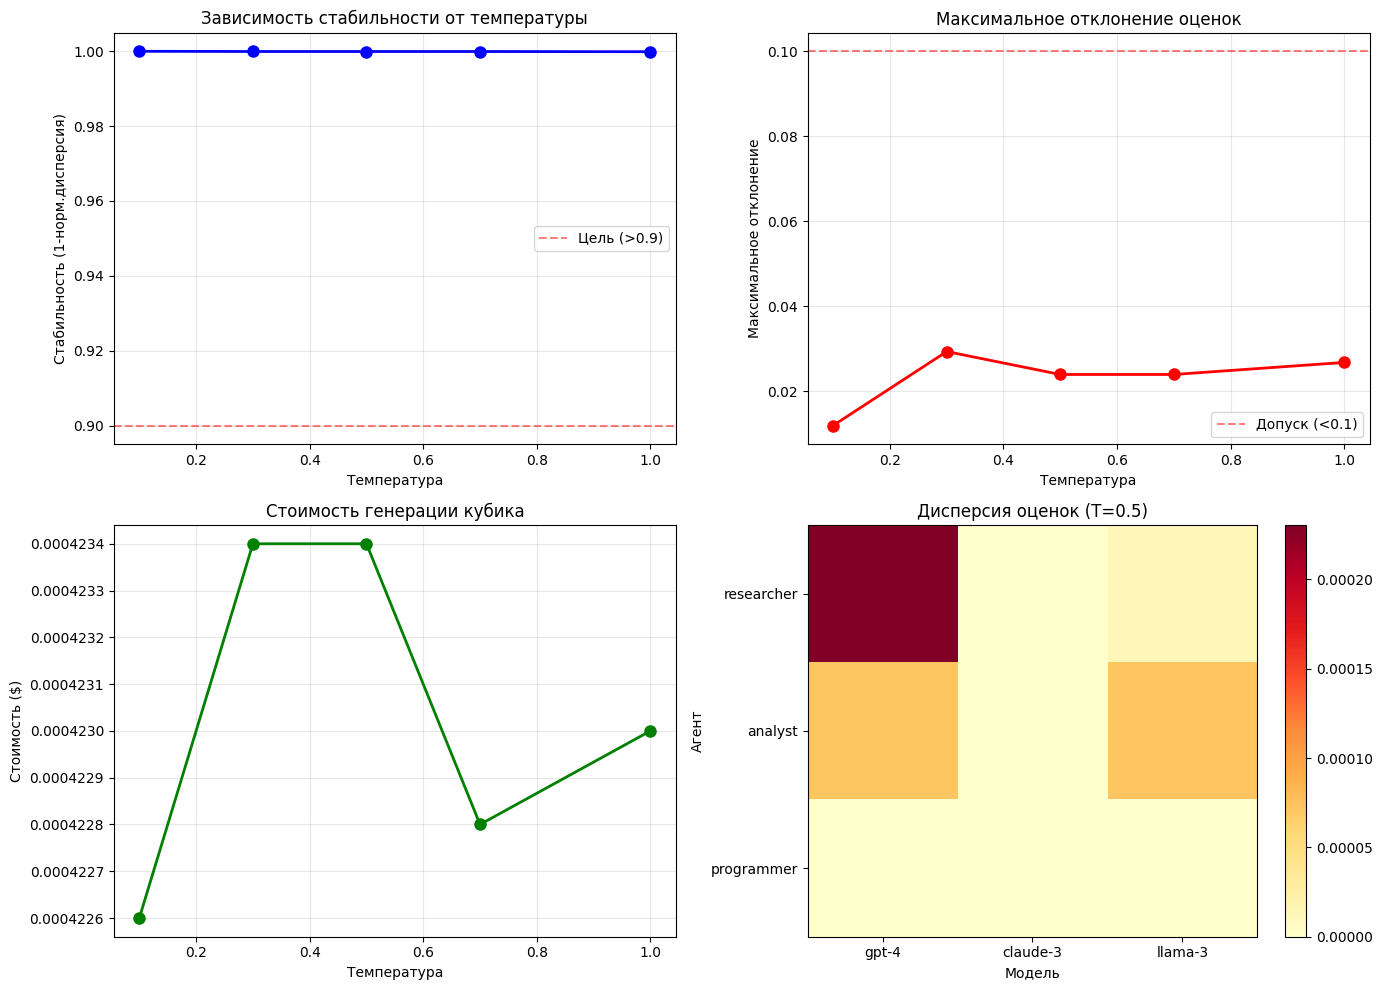


СРАВНЕНИЕ МОДЕЛЕЙ-ОЦЕНЩИКОВ: gpt4, claude3, llama3 (по 3 прогона, T=0.1)

Оценщик: gpt4
  прогон 1/3... $0.0004
  прогон 2/3... $0.0004
  прогон 3/3... $0.0004

Оценщик: claude3
  прогон 1/3... $0.0010
  прогон 2/3... $0.0010
  прогон 3/3... $0.0010

Оценщик: llama3
  прогон 1/3... $0.0001
  прогон 2/3... $0.0001
  прогон 3/3... $0.0001

Оценщик       Стабильность   Стоимость  Макс.откл.  Ср.оценка
--------------------------------------------------------------
gpt4                 1.000 $    0.0004       0.028      0.337
claude3              1.000 $    0.0010       0.000      0.333
llama3               1.000 $    0.0001       0.042      0.341

Лучший по стабильности: claude3 (1.000)

Сохранено: experiments/stability_baseline_3agents_3models.json


In [18]:
analyzer = OracleStabilityAnalyzer(
    oracle_class=OptimizedOracleFixed,
    subtasks=subtasks,
    agents=agents,
    model_packages=model_packages,
)

stability_runs = analyzer.run_stability_experiment(
    n_runs=5,
    use_llm_for=0.3,
    temperatures=[0.1, 0.3, 0.5, 0.7, 1.0],
    oracle_model="gpt4",
)

stability_analysis = analyzer.analyze_stability()
analyzer.visualize_stability_results(f"{RESULTS_DIR}/stability_analysis_{RUN_TAG}.png")

model_comparison = analyzer.compare_oracle_models(
    oracle_models=["gpt4", "claude3", "llama3"],
    n_runs_per_model=3,
)

summary = {
    "by_temperature": {
        str(t): {k: v for k, v in m.items() if not isinstance(v, np.ndarray)}
        for t, m in stability_analysis.items()
    },
    "by_oracle_model": {
        name: {k: v for k, v in res["stability_metrics"].items() if not isinstance(v, np.ndarray)}
        for name, res in model_comparison.items()
    },
}
with open(f"{RESULTS_DIR}/stability_{RUN_TAG}.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2, default=float)
print(f"\nСохранено: {RESULTS_DIR}/stability_{RUN_TAG}.json")

Загрузка GAIA

GAIA — закрытый датасет: нужен HF-токен и принятые условия на странице gaia-benchmark/GAIA. Берём split validation (165 задач) — только в нём есть Annotator Metadata с шагами решения.

In [19]:
from huggingface_hub import login
from datasets import load_dataset

login(token=os.environ["HF_TOKEN"], add_to_git_credential=False)

dataset = None
for config in ["2023_all", "2023_level1", "2023_level2", "2023_level3"]:
    try:
        dataset = load_dataset("gaia-benchmark/GAIA", config, split="validation")
        print(f"Загружено с конфигурацией: {config}")
        break
    except Exception as exc:
        print(f"Конфигурация {config} не сработала: {str(exc)[:120]}")

if dataset is None:
    raise RuntimeError(
        "GAIA не загрузилась. Проверьте: (1) токен HF, (2) принятие условий доступа "
        "на huggingface.co/datasets/gaia-benchmark/GAIA"
    )

df = dataset.to_pandas()
print(f"\nЗадач: {len(df)} | колонки: {df.columns.tolist()}")
print(f"Распределение по уровням:\n{df['Level'].value_counts().sort_index()}")
df[["task_id", "Level", "Question"]].head(5)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


README.md:   0%|          | 0.00/3.29k [00:00<?, ?B/s]

C:\Users\loalm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\loalm\.cache\huggingface\hub\datasets--gaia-benchmark--GAIA. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


2023/test/metadata.parquet:   0%|          | 0.00/75.3k [00:00<?, ?B/s]

2023/validation/metadata.parquet:   0%|          | 0.00/117k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/301 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/165 [00:00<?, ? examples/s]

Загружено с конфигурацией: 2023_all

Задач: 165 | колонки: ['task_id', 'Question', 'Level', 'Final answer', 'file_name', 'file_path', 'Annotator Metadata']
Распределение по уровням:
Level
1    53
2    86
3    26
Name: count, dtype: int64


,task_id,Level,Question
0,c61d22de-5f6c-4958-a7f6-5e9707bd3466,2,A paper about AI regulation that was originall...
1,17b5a6a3-bc87-42e8-b0fb-6ab0781ef2cc,2,I’m researching species that became invasive a...
2,04a04a9b-226c-43fd-b319-d5e89743676f,2,If we assume all articles published by Nature ...
3,14569e28-c88c-43e4-8c32-097d35b9a67d,2,"In Unlambda, what exact charcter or text needs..."
4,e1fc63a2-da7a-432f-be78-7c4a95598703,1,If Eliud Kipchoge could maintain his record-ma...


Извлечение подзадач из Annotator Metadata

Декомпозиция берётся из готовых шагов аннотатора (поле Steps), тип подзадачи определяется по ключевым словам.

In [20]:
TASK_TYPE_KEYWORDS = [
    (TaskType.RESEARCH,      ["find", "search", "look up", "gather", "identify", "go to", "navigate"]),
    (TaskType.ANALYSIS,      ["analyze", "compare", "calculate", "evaluate", "assess", "parse", "count"]),
    (TaskType.CODING,        ["code", "program", "implement", "function", "write code", "python"]),
    (TaskType.REASONING,     ["reason", "deduce", "infer", "if-then", "consider", "evaluate"]),
    (TaskType.SUMMARIZATION, ["summarize", "conclude", "write", "report", "format", "organize"]),
]


def classify_step(step_text: str) -> TaskType:
    """Тип подзадачи по ключевым словам в тексте шага. Если не найдено — ANALYSIS."""
    text = str(step_text).lower()
    for task_type, keywords in TASK_TYPE_KEYWORDS:
        if any(word in text for word in keywords):
            return task_type
    return TaskType.ANALYSIS


def extract_subtasks_from_metadata(metadata_str, task_id: str, task_index: int) -> List[Subtask]:
    """Достаёт шаги из Annotator Metadata и превращает их в типизированные подзадачи."""
    try:
        metadata = json.loads(metadata_str) if isinstance(metadata_str, str) else metadata_str
        steps = metadata.get("Steps", [])

        if isinstance(steps, str):
            if "\n" in steps:
                parsed = []
                for line in (l.strip() for l in steps.split("\n") if l.strip()):
                    for num in range(1, 20):                      # снимаем нумерацию "1. ", "2. "
                        prefix = f"{num}. "
                        if line.startswith(prefix):
                            parsed.append(line[len(prefix):])
                            break
                    else:
                        parsed.append(line)
                steps = parsed
            else:
                steps = [steps]

        return [
            Subtask(
                id=f"{task_id}_step_{i}",
                description=str(step),
                task_type=classify_step(step),
                parent_task_id=task_id,
                step_number=i,
            )
            for i, step in enumerate(steps, 1)
        ]

    except Exception as exc:
        print(f"Ошибка парсинга метаданных задачи {task_index}: {exc}")
        return [Subtask(f"{task_id}_default", f"Task {task_index}: Error parsing metadata",
                        TaskType.ANALYSIS, task_id, 1)]


# проверка на первых 3 задачах
for i in range(3):
    row = df.iloc[i]
    parsed = extract_subtasks_from_metadata(row["Annotator Metadata"], row["task_id"], i + 1)
    print(f"\nЗадача #{i + 1} (уровень {row['Level']}): {len(parsed)} подзадач")
    for st in parsed[:4]:
        print(f"   [{st.task_type.value:<15}] {st.description[:70]}")


Задача #1 (уровень 2): 12 подзадач
   [research       ] Go to arxiv.org and navigate to the Advanced Search page.
   [research       ] Enter "AI regulation" in the search box and select "All fields" from t
   [research       ] Enter 2022-06-01 and 2022-07-01 into the date inputs, select "Submissi
   [research       ] Go through the search results to find the article that has a figure wi

Задача #2 (уровень 2): 10 подзадач
   [research       ] Search the web for “finding nemo main character”.
   [analysis       ] Note the results, which state that the main character is a clownfish.
   [research       ] Search the web for “usgs nonnative species database”.
   [analysis       ] Click result for the Nonindigenous Aquatic Species site.

Задача #3 (уровень 2): 3 подзадач
   [research       ] Find how many articles were published in Nature in 2020 by Googling "a
   [analysis       ] Click through to Nature's archive for 2020 and filter the results to o
   [research       ] Find 4% of 1002 an

ЭКСПЕРИМЕНТ 4: роутеры на 10 задачах GAIA

Ключевая деталь: один оракул на все роутеры - кубик для задачи считается один раз и переиспользуется через кэш, поэтому сравнение идёт на идентичных данных, а платим мы один раз.

In [21]:
def run_gaia_router_comparison(
    df: pd.DataFrame,
    agents: List[Agent],
    model_packages: List[ModelPackage],
    n_tasks: int = 10,
    use_llm_for: float = 0.3,
) -> Tuple[Dict[str, List[Dict]], Dict[str, np.ndarray]]:
    """Сравнивает роутеры на первых n_tasks задачах GAIA на одном и том же кубике."""
    oracle = OptimizedOracleFixed(
        temperature=0.1, model_for_evaluation="gpt4",
        max_tokens_per_eval=15, skip_low_compatibility=True,
    )
    router = SimpleRouter()

    router_methods = {
        "USW": lambda cube: router.utilitarian_allocation(cube),
        "NSW": lambda cube: router.nash_allocation_legacy(cube, fairness_weight=0.7),
        "NSW-fixed": lambda cube: router.nash_allocation_fixed(cube, fairness_weight=0.7),
        "Round Robin": lambda cube: router.round_robin_allocation(cube),
    }

    results_by_router: Dict[str, List[Dict]] = {name: [] for name in router_methods}
    cubes: Dict[str, np.ndarray] = {}

    for i in range(min(n_tasks, len(df))):
        row = df.iloc[i]
        task_subtasks = extract_subtasks_from_metadata(row["Annotator Metadata"], row["task_id"], i + 1)

        cube = oracle.generate_utility_cube_fast(
            task_subtasks, agents, model_packages, use_llm_for=use_llm_for, verbose=False,
        )
        cubes[row["task_id"]] = cube

        print(f"Задача #{i + 1} (уровень {row['Level']}): {len(task_subtasks)} подзадач", end=" | ")

        for name, allocate in router_methods.items():
            allocation = allocate(cube)
            ev = router.evaluate_allocation(allocation, cube)

            results_by_router[name].append({
                "task_id": row["task_id"],
                "level": int(row["Level"]),
                "num_subtasks": len(task_subtasks),
                "total_utility": ev["total_utility"],
                "avg_utility": ev["total_utility"] / len(task_subtasks) if task_subtasks else 0.0,
                "nsw": ev["nsw"],
                "gini": ev["gini"],
                "max_envy": ev["max_envy"],
                "fairness_score": ev["fairness_score"],
                "agent_utilities": {agents[j].role.value: u for j, u in ev["agent_utilities"].items()},
                "model_usage": {model_packages[k].model.value: c for k, c in ev["model_usage_counts"].items()},
                "allocations": allocation,
            })

        print(f"USW={results_by_router['USW'][-1]['total_utility']:.3f}")

    print(f"\nЗатраты оракула: ${oracle.total_cost:.4f} | LLM-вызовов: {oracle.total_evaluations} "
          f"| кэш: {len(oracle.evaluation_cache)}")
    return results_by_router, cubes


results_by_router, gaia_cubes = run_gaia_router_comparison(
    df, agents, model_packages, n_tasks=10, use_llm_for=0.3,
)

# ---------- сводка ----------
print("\n" + "=" * 96)
print("СВОДНАЯ СТАТИСТИКА ПО РОУТЕРАМ (10 задач GAIA)")
print("=" * 96)
print(f"{'Роутер':<13} {'Σ полезн.':>12} {'на подзадачу':>14} {'NSW':>7} {'Gini':>7} {'Envy':>7} "
      f"{'GPT-4':>7} {'Claude':>7} {'Llama':>7}")
print("-" * 96)

for name, res in results_by_router.items():
    totals = [r["total_utility"] for r in res]
    avgs = [r["avg_utility"] for r in res]

    usage = {"gpt-4": 0, "claude-3": 0, "llama-3": 0}
    for r in res:
        for model, count in r["model_usage"].items():
            usage[model] = usage.get(model, 0) + count
    assigned = sum(usage.values()) or 1

    print(f"{name:<13} {np.mean(totals):>7.3f}±{np.std(totals):<4.2f} "
          f"{np.mean(avgs):>9.3f}±{np.std(avgs):<4.2f} "
          f"{np.mean([r['nsw'] for r in res]):>7.3f} {np.mean([r['gini'] for r in res]):>7.3f} "
          f"{np.mean([r['max_envy'] for r in res]):>7.3f} "
          f"{usage['gpt-4'] / assigned:>6.1%} {usage['claude-3'] / assigned:>7.1%} {usage['llama-3'] / assigned:>7.1%}")

baseline = np.mean([r["total_utility"] for r in results_by_router["Round Robin"]])
print("\nПрирост к Round Robin:")
for name, res in results_by_router.items():
    if name != "Round Robin":
        gain = (np.mean([r["total_utility"] for r in res]) - baseline) / baseline * 100
        print(f"  {name:<13} {gain:+.1f}%")

Задача #1 (уровень 2): 12 подзадач | USW=8.600
Задача #2 (уровень 2): 10 подзадач | USW=6.830
Задача #3 (уровень 2): 3 подзадач | USW=2.050
Задача #4 (уровень 2): 6 подзадач | USW=4.250
Задача #5 (уровень 1): 4 подзадач | USW=2.720
Задача #6 (уровень 2): 3 подзадач | USW=2.200
Задача #7 (уровень 1): 4 подзадач | USW=2.670
Задача #8 (уровень 2): 10 подзадач | USW=7.395
Задача #9 (уровень 2): 9 подзадач | USW=6.190
Задача #10 (уровень 1): 13 подзадач | USW=9.172

Затраты оракула: $0.0066 | LLM-вызовов: 194 | кэш: 197

СВОДНАЯ СТАТИСТИКА ПО РОУТЕРАМ (10 задач GAIA)
Роутер           Σ полезн.   на подзадачу     NSW    Gini    Envy   GPT-4  Claude   Llama
------------------------------------------------------------------------------------------------
USW             5.208±2.61     0.700±0.02   0.178   0.446   1.437  97.3%    1.4%    1.4%
NSW             4.148±2.49     0.546±0.09   0.000   0.667   3.697 100.0%    0.0%    0.0%
NSW-fixed       5.187±2.59     0.698±0.02   0.178   0.437   1.738 

Графики и сохранение baseline

(4 панели: средняя полезность, разброс по задачам, использование моделей, нагрузка агентов)

График сохранён: experiments/compare_routers_baseline_3agents_3models.png


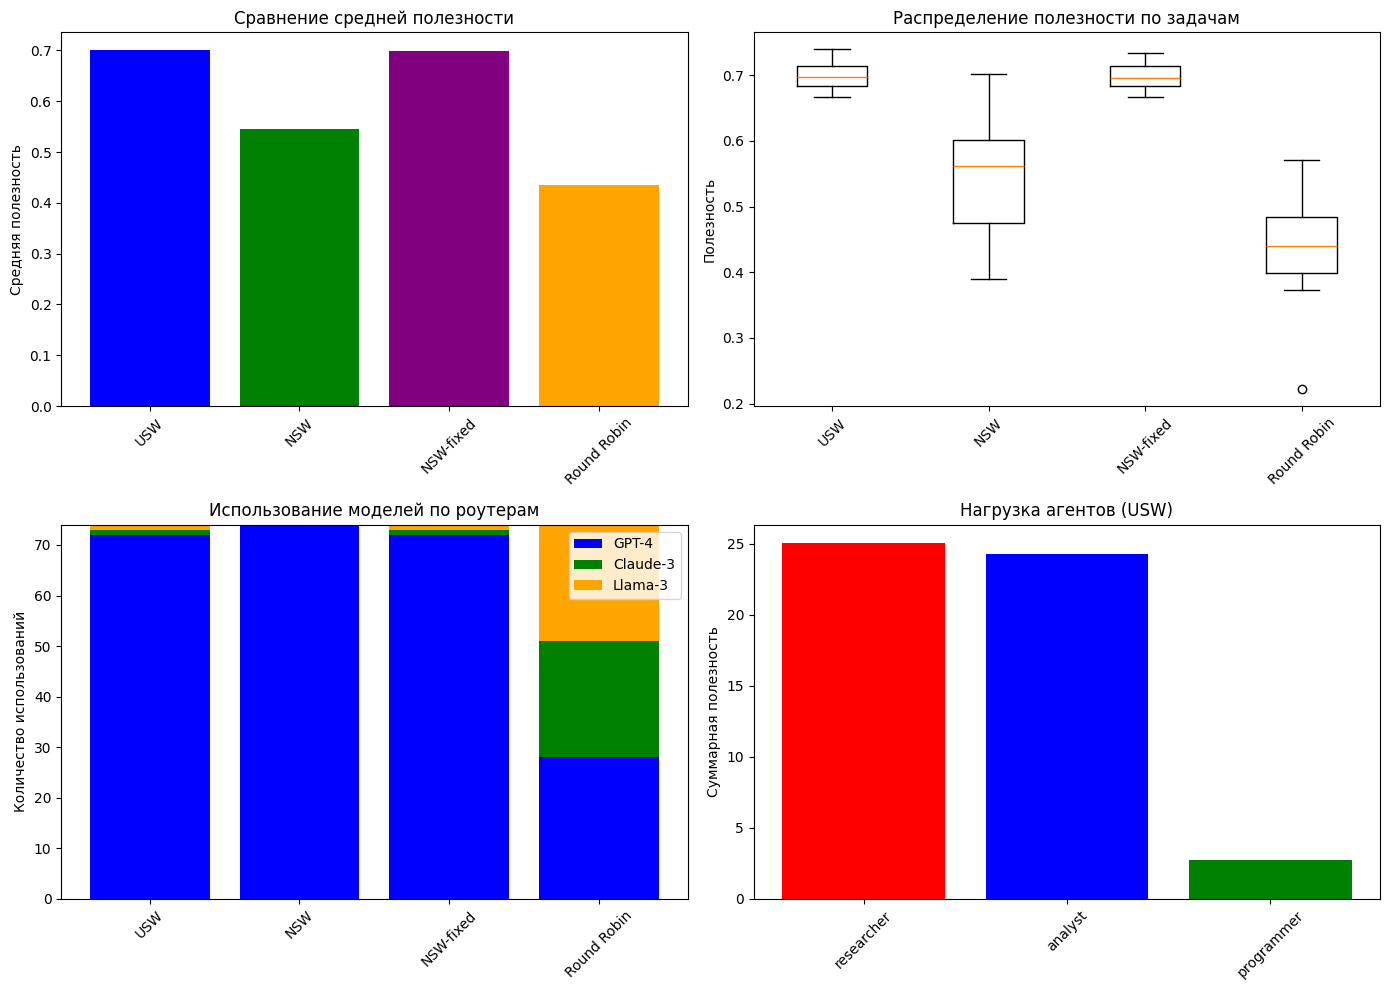


Baseline сохранён:
  experiments/gaia_routers_baseline_3agents_3models.json
  experiments/gaia_routers_baseline_3agents_3models.csv
  experiments/cube_baseline_3agents_3models.npy
  experiments/stability_baseline_3agents_3models.json
  experiments/compare_routers_baseline_3agents_3models.png
  experiments/stability_analysis_baseline_3agents_3models.png


In [22]:
def visualize_router_comparison(results_by_router: Dict[str, List[Dict]],
                                agents: List[Agent],
                                save_path: Optional[str] = None) -> None:
    names = list(results_by_router)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    palette = ["blue", "green", "purple", "orange", "brown"][:len(names)]

    # 1. средняя полезность на подзадачу
    avg_utilities = [np.mean([r["avg_utility"] for r in results_by_router[n]]) for n in names]
    axes[0, 0].bar(names, avg_utilities, color=palette)
    axes[0, 0].set(ylabel="Средняя полезность", title="Сравнение средней полезности")
    axes[0, 0].tick_params(axis="x", rotation=45)

    # 2. разброс по задачам
    data = [[r["avg_utility"] for r in results_by_router[n]] for n in names]
    try:
        axes[0, 1].boxplot(data, tick_labels=names)          # matplotlib >= 3.9
    except TypeError:
        axes[0, 1].boxplot(data, labels=names)
    axes[0, 1].set(ylabel="Полезность", title="Распределение полезности по задачам")
    axes[0, 1].tick_params(axis="x", rotation=45)

    # 3. использование моделей
    model_labels = {"gpt-4": "GPT-4", "claude-3": "Claude-3", "llama-3": "Llama-3"}
    colors = {"GPT-4": "blue", "Claude-3": "green", "Llama-3": "orange"}
    bottom = np.zeros(len(names))

    for raw, label in model_labels.items():
        values = [sum(r["model_usage"].get(raw, 0) for r in results_by_router[n]) for n in names]
        axes[1, 0].bar(names, values, bottom=bottom, label=label, color=colors[label])
        bottom += np.array(values, dtype=float)

    axes[1, 0].set(ylabel="Количество использований", title="Использование моделей по роутерам")
    axes[1, 0].legend(); axes[1, 0].tick_params(axis="x", rotation=45)

    # 4. нагрузка агентов (USW)
    roles = [a.role.value for a in agents]
    loads = {role: 0.0 for role in roles}
    for r in results_by_router.get("USW", []):
        for role, utility in r["agent_utilities"].items():
            loads[role] = loads.get(role, 0.0) + utility

    axes[1, 1].bar(roles, [loads[r] for r in roles], color=["red", "blue", "green"][:len(roles)])
    axes[1, 1].set(ylabel="Суммарная полезность", title="Нагрузка агентов (USW)")
    axes[1, 1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"График сохранён: {save_path}")
    plt.show()


visualize_router_comparison(results_by_router, agents, f"{RESULTS_DIR}/compare_routers_{RUN_TAG}.png")

# ---------- сохранение baseline ----------
artifact = {
    "run_tag": RUN_TAG,
    "timestamp": datetime.now().isoformat(),
    "config": {
        "agents": [{"id": a.id, "role": a.role.value, "tools": a.tools} for a in agents],
        "model_packages": [
            {"model": p.model.value, "openrouter_id": MODEL_CONFIGS[key].openrouter_id,
             "token_budget": p.token_budget, "cost": p.cost}
            for p, key in zip(model_packages, MODEL_CONFIGS)
        ],
        "oracle": {"temperature": 0.1, "model_for_evaluation": "gpt4",
                   "use_llm_for": 0.3, "max_tokens_per_eval": 15},
        "gaia": {"split": "validation", "n_tasks": 10},
    },
    "results_by_router": results_by_router,
}

with open(f"{RESULTS_DIR}/gaia_routers_{RUN_TAG}.json", "w", encoding="utf-8") as f:
    json.dump(artifact, f, ensure_ascii=False, indent=2, default=float)

pd.concat(
    [pd.DataFrame(res).assign(router=name) for name, res in results_by_router.items()],
    ignore_index=True,
).to_csv(f"{RESULTS_DIR}/gaia_routers_{RUN_TAG}.csv", index=False)

print(f"\nBaseline сохранён:")
print(f"  {RESULTS_DIR}/gaia_routers_{RUN_TAG}.json")
print(f"  {RESULTS_DIR}/gaia_routers_{RUN_TAG}.csv")
print(f"  {RESULTS_DIR}/cube_{RUN_TAG}.npy")
print(f"  {RESULTS_DIR}/stability_{RUN_TAG}.json")
print(f"  {RESULTS_DIR}/compare_routers_{RUN_TAG}.png")
print(f"  {RESULTS_DIR}/stability_analysis_{RUN_TAG}.png")

Проблема «специализация агентов не используется, программист получает 1% задач», скорее всего, не свойство механизма распределения, а артефакт типизации шагов. Правила проверяются по порядку, ANALYSIS идёт раньше REASONING, а слово evaluate есть в обоих списках → REASONING почти никогда не срабатывает.
Fallback - тоже ANALYSIS, то есть всё неопознанное валится в анализ.
CODING ловится только по словам code / program / implement / function / python, а gold-шаги GAIA написаны языком веб-поиска («open», «navigate», «find») --> тип CODING почти не появляется.
Значит, у программиста просто нет задач его профиля. Матрица совместимости честно ставит ему 0.2-0.5, роутер честно его не выбирает. Механизм ни при чём.

Посмотрим есть ли в 10 задачах вообще задачи для программиста.

In [23]:
from collections import Counter

# распределение типов подзадач по 10 задачам GAIA (то, что видел роутер)
type_counter = Counter()
fallback_examples = []

for i in range(10):
    row = df.iloc[i]
    for st in extract_subtasks_from_metadata(row["Annotator Metadata"], row["task_id"], i + 1):
        type_counter[st.task_type.value] += 1
        # шаги, которые не попали ни под одно правило и ушли в ANALYSIS по умолчанию
        text = st.description.lower()
        matched = any(
            any(w in text for w in kws) for _, kws in TASK_TYPE_KEYWORDS
        )
        if not matched:
            fallback_examples.append(st.description[:90])

total_steps = sum(type_counter.values())
print(f"Всего подзадач: {total_steps}\n")
print(f"{'Тип':<18} {'шт':>4} {'доля':>7}")
print("-" * 32)
for t in TaskType:
    c = type_counter.get(t.value, 0)
    print(f"{t.value:<18} {c:>4} {c / total_steps:>6.1%}")

print(f"\nШагов, ушедших в ANALYSIS по fallback (ни одно правило не сработало): "
      f"{len(fallback_examples)} ({len(fallback_examples) / total_steps:.1%})")
for ex in fallback_examples[:8]:
    print(f"   • {ex}")

# сколько подзадач вообще «профильны» для каждого агента:
# считаем, для скольких шагов агент — лучший по матрице совместимости оракула
best_role = Counter()
for t_name, count in type_counter.items():
    t = TaskType(t_name)
    scores = {
        role: OptimizedOracleFixed.ROLE_TASK_COMPATIBILITY[role][t]
        for role in [AgentRole.RESEARCHER, AgentRole.ANALYST, AgentRole.PROGRAMMER]
    }
    best_role[max(scores, key=scores.get).value] += count

print(f"\nДля скольких подзадач агент является профильным (argmax по матрице роль×тип):")
for role, c in best_role.most_common():
    print(f"   {role:<12} {c:>4} ({c / total_steps:.1%})")

Всего подзадач: 74

Тип                  шт    доля
--------------------------------
research             30  40.5%
analysis             37  50.0%
coding                4   5.4%
reasoning             2   2.7%
summarization         1   1.4%

Шагов, ушедших в ANALYSIS по fallback (ни одно правило не сработало): 32 (43.2%)
   • Note the six words used as labels: deontological, egalitarian, localized, standardized, ut
   • Go back to arxiv.org
   • Note that the tag for this category is "physics.soc-ph".
   • Note the results, which state that the main character is a clownfish.
   • Click result for the Nonindigenous Aquatic Species site.
   • Click “Marine Fishes”.
   • Click “Species List of Nonindigenous Marine Fish”.
   • Note the place that a clown anenomefish was found, in Fred Howard Park at the Gulf of Mexi

Для скольких подзадач агент является профильным (argmax по матрице роль×тип):
   analyst        40 (54.1%)
   researcher     30 (40.5%)
   programmer      4 (5.4%)
